# Dengue Outbreak Prediction Using Climate and Environmental Data

Group RAG


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import TweedieRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# `1. Data Understanding and Preprocessing`

In [2]:
train_features = pd.read_csv("dengue_features_train.csv")
train_labels = pd.read_csv("dengue_labels_train.csv")
test_features = pd.read_csv("dengue_features_test.csv")

print(train_features.shape)
print(train_labels.shape)
print(test_features.shape)

train_features.head()

(1456, 24)
(1456, 4)
(416, 24)


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


In [3]:
df = train_features.merge(train_labels, on=["city", "year", "weekofyear"]) # Combine features and labels for easier processing

df["week_start_date"] = pd.to_datetime(df["week_start_date"])
df = df.sort_values(["city", "week_start_date"]).reset_index(drop=True)

print(df.shape)
df.head()

(1456, 25)


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
0,iq,2000,26,2000-07-01,0.192886,0.132257,0.340886,0.247200,25.41,296.740000,...,92.418571,25.41,16.651429,8.928571,26.400000,10.775000,32.5,20.7,3.0,0
1,iq,2000,27,2000-07-08,0.216833,0.276100,0.289457,0.241657,60.61,296.634286,...,93.581429,60.61,16.862857,10.314286,26.900000,11.566667,34.0,20.8,55.6,0
2,iq,2000,28,2000-07-15,0.176757,0.173129,0.204114,0.128014,55.52,296.415714,...,95.848571,55.52,17.120000,7.385714,26.800000,11.466667,33.0,20.7,38.1,0
3,iq,2000,29,2000-07-22,0.227729,0.145429,0.254200,0.200314,5.60,295.357143,...,87.234286,5.60,14.431429,9.114286,25.766667,10.533333,31.5,14.7,30.0,0
4,iq,2000,30,2000-07-29,0.328643,0.322129,0.254371,0.361043,62.76,296.432857,...,88.161429,62.76,15.444286,9.500000,26.600000,11.480000,33.3,19.1,4.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   city                                   1456 non-null   object        
 1   year                                   1456 non-null   int64         
 2   weekofyear                             1456 non-null   int64         
 3   week_start_date                        1456 non-null   datetime64[ns]
 4   ndvi_ne                                1262 non-null   float64       
 5   ndvi_nw                                1404 non-null   float64       
 6   ndvi_se                                1434 non-null   float64       
 7   ndvi_sw                                1434 non-null   float64       
 8   precipitation_amt_mm                   1443 non-null   float64       
 9   reanalysis_air_temp_k                  1446 non-null   float64 

In [5]:
df.describe()

,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
count,1456.000000,1456.000000,1456,1262.000000,1404.000000,1434.000000,1434.000000,1443.000000,1446.000000,1446.000000,...,1446.000000,1443.000000,1446.000000,1446.000000,1413.000000,1413.000000,1436.000000,1442.000000,1434.000000,1456.000000
mean,2001.031593,26.503434,2001-07-09 16:01:19.120879104,0.142294,0.130553,0.203783,0.202305,45.760388,298.701852,299.225578,...,82.161959,45.760388,16.746427,4.903754,27.185783,8.059328,32.452437,22.102150,39.326360,24.675137
min,1990.000000,1.000000,1990-04-30 00:00:00,-0.406250,-0.456100,-0.015533,-0.063457,0.000000,294.635714,294.892857,...,57.787143,0.000000,11.715714,1.357143,21.400000,4.528571,26.700000,14.700000,0.000000,0.000000
25%,1997.000000,13.750000,1997-04-28 06:00:00,0.044950,0.049217,0.155087,0.144209,9.800000,297.658929,298.257143,...,77.177143,9.800000,15.557143,2.328571,26.300000,6.514286,31.100000,21.100000,8.700000,5.000000
50%,2002.000000,26.500000,2002-05-28 00:00:00,0.128817,0.121429,0.196050,0.189450,38.340000,298.646429,299.289286,...,80.301429,38.340000,17.087143,2.857143,27.414286,7.300000,32.800000,22.200000,23.850000,12.000000
75%,2005.000000,39.250000,2005-11-26 00:00:00,0.248483,0.216600,0.248846,0.246982,70.235000,299.833571,300.207143,...,86.357857,70.235000,17.978214,7.625000,28.157143,9.566667,33.900000,23.300000,53.900000,28.000000
max,2010.000000,53.000000,2010-06-25 00:00:00,0.508357,0.454429,0.538314,0.546017,390.600000,302.200000,302.928571,...,98.610000,390.600000,20.461429,16.028571,30.800000,15.800000,42.200000,25.600000,543.300000,461.000000
std,5.408314,15.019437,NaN,0.140531,0.119999,0.073860,0.083903,43.715537,1.362420,1.261715,...,7.153897,43.715537,1.542494,3.546445,1.292347,2.128568,1.959318,1.574066,47.455314,43.596000


In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

ndvi_ne                                  194
ndvi_nw                                   52
station_avg_temp_c                        43
station_diur_temp_rng_c                   43
ndvi_se                                   22
ndvi_sw                                   22
station_precip_mm                         22
station_max_temp_c                        20
station_min_temp_c                        14
precipitation_amt_mm                      13
reanalysis_sat_precip_amt_mm              13
reanalysis_min_air_temp_k                 10
reanalysis_max_air_temp_k                 10
reanalysis_relative_humidity_percent      10
reanalysis_precip_amt_kg_per_m2           10
reanalysis_dew_point_temp_k               10
reanalysis_air_temp_k                     10
reanalysis_avg_temp_k                     10
reanalysis_tdtr_k                         10
reanalysis_specific_humidity_g_per_kg     10
city                                       0
weekofyear                                 0
year      

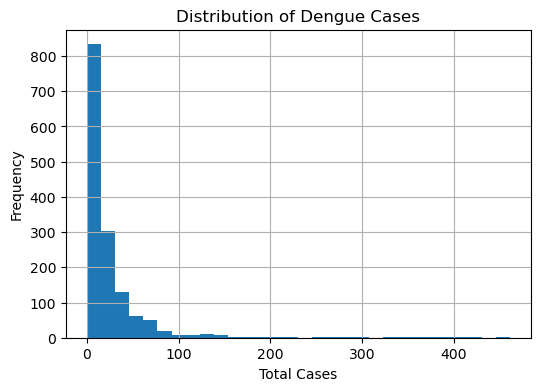

In [7]:
plt.figure(figsize=(6,4))
df["total_cases"].hist(bins=30)
plt.title("Distribution of Dengue Cases")
plt.xlabel("Total Cases")
plt.ylabel("Frequency")
plt.show()

In [8]:
df = df.fillna(df.mean(numeric_only=True))
df = df.drop("week_start_date", axis=1)
df = pd.get_dummies(df, columns=["city"], drop_first=True)

In [9]:
X = df.drop("total_cases", axis=1)
y = df["total_cases"]

print(X.shape)
print(y.shape)

(1456, 23)
(1456,)


In [10]:
df.isnull().sum()

year                                     0
weekofyear                               0
ndvi_ne                                  0
ndvi_nw                                  0
ndvi_se                                  0
ndvi_sw                                  0
precipitation_amt_mm                     0
reanalysis_air_temp_k                    0
reanalysis_avg_temp_k                    0
reanalysis_dew_point_temp_k              0
reanalysis_max_air_temp_k                0
reanalysis_min_air_temp_k                0
reanalysis_precip_amt_kg_per_m2          0
reanalysis_relative_humidity_percent     0
reanalysis_sat_precip_amt_mm             0
reanalysis_specific_humidity_g_per_kg    0
reanalysis_tdtr_k                        0
station_avg_temp_c                       0
station_diur_temp_rng_c                  0
station_max_temp_c                       0
station_min_temp_c                       0
station_precip_mm                        0
total_cases                              0
city_sj    

## Initial Preprocessing and Time-Aware Train/Validation Split

In [11]:
df = train_features.merge(train_labels, on=["city", "year", "weekofyear"])
df["week_start_date"] = pd.to_datetime(df["week_start_date"])
df = df.sort_values(["city", "week_start_date"]).reset_index(drop=True)

def split_last_n_weeks_per_city(df, n_weeks=52, date_col="week_start_date", city_col="city"):
    train_parts, val_parts = [], []
    for city, g in df.groupby(city_col):
        g = g.sort_values(date_col).reset_index(drop=True)

        if len(g) <= n_weeks:
            cut = int(len(g) * 0.8)
            train_parts.append(g.iloc[:cut])
            val_parts.append(g.iloc[cut:])
        else:
            train_parts.append(g.iloc[:-n_weeks])
            val_parts.append(g.iloc[-n_weeks:])

    train_df = pd.concat(train_parts).reset_index(drop=True)
    val_df = pd.concat(val_parts).reset_index(drop=True)
    return train_df, val_df

# Keep raw train_df / val_df for baseline models that need `city`
train_df, val_df = split_last_n_weeks_per_city(df, n_weeks=52)

def preprocess_for_model(data):
    data = data.copy()
    data = data.fillna(data.mean(numeric_only=True))
    data = data.drop("week_start_date", axis=1, errors="ignore")
    return data

# Optional model-ready copies (still keep raw train_df / val_df unchanged)
train_df_model = preprocess_for_model(train_df)
val_df_model = preprocess_for_model(val_df)


# `2. Analyze Model Performance`

In [12]:
TARGET = "total_cases"
DROP_COLS = ["week_start_date"]

def make_X_y(df):
    X = df.drop(columns=[TARGET] + DROP_COLS, errors="ignore").copy()

    # Encode city only when building model features.
    if "city" in X.columns:
        X = pd.get_dummies(X, columns=["city"], drop_first=True)

    y = df[TARGET].astype(float).copy()
    return X, y

def clip_nonnegative(pred):
    pred = np.asarray(pred, dtype=float)
    return np.clip(pred, 0, None)


In [13]:
def compute_metrics(y_true, y_pred):
    y_pred = clip_nonnegative(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}


## 2.1 Baseline Model: Seasonal Mean Forecast

In [14]:
def seasonal_mean_baseline_predict(train_df, eval_df):
    """
    Predicts using the average case count per (city, weekofyear) from the training set.
    If a weekofyear in eval was never seen during training for that city,
    falls back to the city-level overall mean.
    """
    # Overall mean per city (fallback)
    city_mean = train_df.groupby("city")[TARGET].mean()
    # Seasonal mean per city per week
    wk_mean = train_df.groupby(["city", "weekofyear"])[TARGET].mean()

    # Generate predictions
    preds = []
    for _, row in eval_df[["city", "weekofyear"]].iterrows():
        key = (row["city"], row["weekofyear"])
        if key in wk_mean.index:
            preds.append(wk_mean.loc[key])
        else:
            preds.append(city_mean.loc[row["city"]])
    return np.array(preds, dtype=float)


def evaluate_baseline(train_df, val_df):
    y_val = val_df[TARGET].values
    pred_val = seasonal_mean_baseline_predict(train_df, val_df)

    # Overall metrics
    overall = compute_metrics(y_val, pred_val)

    # Per-city metrics
    by_city = {}
    for city in val_df["city"].unique():
        mask = val_df["city"] == city
        by_city[city] = compute_metrics(y_val[mask], pred_val[mask])

    return overall, by_city


baseline_overall, baseline_by_city = evaluate_baseline(train_df, val_df)
print("Baseline (Seasonal Mean) - Overall:", baseline_overall)
print("Baseline (Seasonal Mean) - By City:")
for c, m in baseline_by_city.items():
    print(f"  {c}: {m}")

Baseline (Seasonal Mean) - Overall: {'MAE': 12.501665409753645, 'RMSE': np.float64(19.855610475967016)}
Baseline (Seasonal Mean) - By City:
  iq: {'MAE': 4.6068376068376065, 'RMSE': np.float64(6.034720685432515)}
  sj: {'MAE': 20.396493212669682, 'RMSE': np.float64(27.423943571183834)}


In [15]:
def get_numeric_feature_cols(df):
    """Returns numeric feature columns used for modeling (excludes target, city, and date columns)."""
    drop = {TARGET, "city", "week_start_date"}
    cols = [c for c in df.columns if c not in drop]
    num_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    return num_cols


def postprocess_pred(pred, round_to_int=True):
    pred = clip_nonnegative(pred)
    if round_to_int:
        pred = np.rint(pred)  # Round to nearest integer
        pred = clip_nonnegative(pred)
    return pred


def evaluate_model_per_city(
    train_df, val_df,
    estimator_factory,
    model_name,
    scale_features=False,
    round_to_int=True
):
    """
    Trains and evaluates a separate model per city, then aggregates overall metrics.

    Args:
        estimator_factory: A callable that returns a new sklearn estimator instance
                           (called once per city to ensure independence).
        model_name:        Label for this model in the results table.
        scale_features:    Whether to apply StandardScaler before the estimator.
        round_to_int:      Whether to round predictions to the nearest integer.

    Returns:
        results_df: A long-format DataFrame with one row per city + one overall row,
                    containing MAE and RMSE for each.
    """
    num_cols = get_numeric_feature_cols(train_df)
    rows = []

    # Collect predictions across all cities for overall metrics
    y_all, pred_all = [], []

    for city in sorted(val_df["city"].unique()):
        tr = train_df[train_df["city"] == city].copy()
        va = val_df[val_df["city"] == city].copy()

        X_tr = tr[num_cols]
        y_tr = tr[TARGET].values
        X_va = va[num_cols]
        y_va = va[TARGET].values

        steps = [("imputer", SimpleImputer(strategy="mean"))]
        if scale_features:
            steps.append(("scaler", StandardScaler()))
        steps.append(("model", estimator_factory()))

        pipe = Pipeline(steps)
        pipe.fit(X_tr, y_tr)

        pred = pipe.predict(X_va)
        pred = postprocess_pred(pred, round_to_int=round_to_int)

        m = compute_metrics(y_va, pred)
        rows.append({
            "model": model_name,
            "city":  city,
            "n":     len(y_va),
            "MAE":   m["MAE"],
            "RMSE":  m["RMSE"]
        })
        y_all.append(y_va)
        pred_all.append(pred)

    # Overall metrics across all cities
    y_all    = np.concatenate(y_all)
    pred_all = np.concatenate(pred_all)
    m_all    = compute_metrics(y_all, pred_all)
    rows.append({
        "model": model_name,
        "city":  "overall",
        "n":     len(y_all),
        "MAE":   m_all["MAE"],
        "RMSE":  m_all["RMSE"]
    })

    results_df = pd.DataFrame(rows).sort_values(["model", "city"]).reset_index(drop=True)
    return results_df

In [16]:
# Example usage with a simple estimator (e.g., LinearRegression)
baseline_rows = []
for city, m in baseline_by_city.items():
    baseline_rows.append({"model": "Baseline_SeasonalMean", "city": city, "n": int((val_df["city"]==city).sum()),
                          "MAE": m["MAE"], "RMSE": m["RMSE"]})
baseline_rows.append({"model": "Baseline_SeasonalMean", "city": "overall", "n": len(val_df),
                      "MAE": baseline_overall["MAE"], "RMSE": baseline_overall["RMSE"]})

results_all = pd.DataFrame(baseline_rows)
results_all

,model,city,n,MAE,RMSE
0,Baseline_SeasonalMean,iq,52,4.606838,6.034721
1,Baseline_SeasonalMean,sj,52,20.396493,27.423944
2,Baseline_SeasonalMean,overall,104,12.501665,19.855610


## 2.2 Regression Models for Weekly Case Prediction

### a) Poisson Regressor

In [17]:


poisson_df = evaluate_model_per_city(
    train_df=train_df,
    val_df=val_df,
    estimator_factory=lambda: PoissonRegressor(alpha=1e-4, max_iter=5000),
    model_name="PoissonRegressor",
    scale_features=True,     # Poisson regression can benefit from feature scaling
    round_to_int=True        # Integer predictions are more appropriate for case counts
)

results_all = pd.concat([results_all, poisson_df], ignore_index=True)
results_all.sort_values(["city", "MAE"])

C:\Users\vincent\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\vincent\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\vincent\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vincent\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

,model,city,n,MAE,RMSE
0,Baseline_SeasonalMean,iq,52,4.606838,6.034721
3,PoissonRegressor,iq,52,11.711538,12.907213
2,Baseline_SeasonalMean,overall,104,12.501665,19.855610
4,PoissonRegressor,overall,104,17.980769,30.032034
1,Baseline_SeasonalMean,sj,52,20.396493,27.423944
5,PoissonRegressor,sj,52,24.250000,40.462946


In [18]:
poisson_no_round_df = evaluate_model_per_city(
    train_df=train_df,
    val_df=val_df,
    estimator_factory=lambda: PoissonRegressor(alpha=1e-4, max_iter=5000),
    model_name="PoissonRegressor_no_round",
    scale_features=True,
    round_to_int=False      # Keep as continuous predictions to see the effect of rounding
)

results_all = pd.concat([results_all, poisson_no_round_df], ignore_index=True)
results_all[results_all["model"].str.contains("Poisson")].sort_values(["city", "MAE"])

,model,city,n,MAE,RMSE
3,PoissonRegressor,iq,52,11.711538,12.907213
6,PoissonRegressor_no_round,iq,52,11.747657,12.949095
4,PoissonRegressor,overall,104,17.980769,30.032034
7,PoissonRegressor_no_round,overall,104,17.988904,30.022539
8,PoissonRegressor_no_round,sj,52,24.230150,40.435463
5,PoissonRegressor,sj,52,24.250000,40.462946


### b) Random Forest Regressor

In [19]:


rf_df = evaluate_model_per_city(
    train_df=train_df,
    val_df=val_df,
    estimator_factory=lambda: RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ),
    model_name="RandomForest",
    scale_features=False,
    round_to_int=False
)

results_all = pd.concat([results_all, rf_df], ignore_index=True)
results_all[results_all["model"]=="RandomForest"].sort_values(["city", "MAE"])

,model,city,n,MAE,RMSE
9,RandomForest,iq,52,7.600743,9.639357
10,RandomForest,overall,104,15.335277,27.715723
11,RandomForest,sj,52,23.069811,37.992175


### c) HistGradientBoosting Regressor

In [20]:

hgb_df = evaluate_model_per_city(
    train_df=train_df,
    val_df=val_df,
    estimator_factory=lambda: HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        max_iter=500,
        random_state=42
    ),
    model_name="HistGradientBoosting",
    scale_features=False,
    round_to_int=False
)

results_all = pd.concat([results_all, hgb_df], ignore_index=True)
results_all[results_all["model"]=="HistGradientBoosting"].sort_values(["city", "MAE"])

,model,city,n,MAE,RMSE
12,HistGradientBoosting,iq,52,6.603392,8.985404
13,HistGradientBoosting,overall,104,15.566605,28.930499
14,HistGradientBoosting,sj,52,24.529818,39.915035


# `3 Interpreting the Initial Regression Results`

In [21]:
results_all[results_all["city"]=="overall"].sort_values("MAE").reset_index(drop=True)

,model,city,n,MAE,RMSE
0,Baseline_SeasonalMean,overall,104,12.501665,19.855610
1,RandomForest,overall,104,15.335277,27.715723
2,HistGradientBoosting,overall,104,15.566605,28.930499
3,PoissonRegressor,overall,104,17.980769,30.032034
4,PoissonRegressor_no_round,overall,104,17.988904,30.022539


## 3.1 Feature Engineering for Temporal Patterns

In [22]:
def add_time_features(df):
    df = df.copy()
    w = df["weekofyear"].astype(int)
    df["week_sin"] = np.sin(2 * np.pi * w / 52.0)
    df["week_cos"] = np.cos(2 * np.pi * w / 52.0)
    return df


def add_lag_rolling_features(df, lags=(1, 2, 3, 4, 8), roll_windows=(4, 8)):
    """
    For each city group, sorted by time:
      - lag_k:         Climate/NDVI values from k weeks ago
      - roll_W_mean:   Rolling mean over the past W weeks (excluding the current week)
    """
    df = df.sort_values(["city", "week_start_date"]).copy()

    # Select numeric columns (excluding year/weekofyear — already present in df)
    exclude = {TARGET, "city", "week_start_date", "year", "weekofyear"}
    num_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]

    g = df.groupby("city", group_keys=False)

    # Lag features
    for lag in lags:
        lag_df = g[num_cols].shift(lag)
        lag_df = lag_df.add_suffix(f"_lag{lag}")
        df = pd.concat([df, lag_df], axis=1)

    # Rolling mean features (shift(1) ensures the current week is not included)
    for w in roll_windows:
        roll_df = g[num_cols].apply(lambda x: x.shift(1).rolling(window=w, min_periods=1).mean())
        roll_df = roll_df.reset_index(level=0, drop=True)  # Align with original index
        roll_df = roll_df.add_suffix(f"_roll{w}_mean")
        df = pd.concat([df, roll_df], axis=1)

    return df


# Starting from the previously merged df (which includes TARGET & week_start_date)
df_fe = add_time_features(df)
df_fe = add_lag_rolling_features(df_fe, lags=(1, 2, 3, 4, 8), roll_windows=(4, 8))

# Re-apply the time-aware train/val split (last 52 weeks as validation)
train_fe, val_fe = split_last_n_weeks_per_city(df_fe, n_weeks=52)
print("train_fe:", train_fe.shape, "| val_fe:", val_fe.shape)
train_fe.head()

train_fe: (1352, 181) | val_fe: (104, 181)


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_sat_precip_amt_mm_roll8_mean,reanalysis_specific_humidity_g_per_kg_roll8_mean,reanalysis_tdtr_k_roll8_mean,station_avg_temp_c_roll8_mean,station_diur_temp_rng_c_roll8_mean,station_max_temp_c_roll8_mean,station_min_temp_c_roll8_mean,station_precip_mm_roll8_mean,week_sin_roll8_mean,week_cos_roll8_mean
0,iq,2000,26,2000-07-01,0.192886,0.132257,0.340886,0.247200,25.41,296.740000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,iq,2000,27,2000-07-08,0.216833,0.276100,0.289457,0.241657,60.61,296.634286,...,25.410,16.651429,8.928571,26.400000,10.775000,32.500000,20.700000,3.000000,-3.216245e-16,-1.000000
2,iq,2000,28,2000-07-15,0.176757,0.173129,0.204114,0.128014,55.52,296.415714,...,43.010,16.757143,9.621429,26.650000,11.170833,33.250000,20.750000,29.300000,-6.026834e-02,-0.996354
3,iq,2000,29,2000-07-22,0.227729,0.145429,0.254200,0.200314,5.60,295.357143,...,47.180,16.878095,8.876190,26.700000,11.269444,33.166667,20.733333,32.233333,-1.199508e-01,-0.987884
4,iq,2000,30,2000-07-29,0.328643,0.322129,0.254371,0.361043,62.76,296.432857,...,36.785,16.266429,8.935714,26.466667,11.085417,32.750000,19.225000,31.675000,-1.786143e-01,-0.974667


In [23]:
# Define FE baseline results so they always exist
if "train_fe" in globals() and "val_fe" in globals():
    train_fe_eval = train_fe.copy()
    val_fe_eval = val_fe.copy()

    # Reconstruct the original city column if city was one-hot encoded
    if "city" not in train_fe_eval.columns and "city_sj" in train_fe_eval.columns:
        train_fe_eval["city"] = np.where(train_fe_eval["city_sj"] == 1, "sj", "iq")

    if "city" not in val_fe_eval.columns and "city_sj" in val_fe_eval.columns:
        val_fe_eval["city"] = np.where(val_fe_eval["city_sj"] == 1, "sj", "iq")

    # Recompute FE baseline only if required columns are available
    required_cols = {"city", "weekofyear", TARGET}

    if required_cols.issubset(train_fe_eval.columns) and required_cols.issubset(val_fe_eval.columns):
        baseline_overall_fe, baseline_by_city_fe = evaluate_baseline(train_fe_eval, val_fe_eval)
    else:
        # Fall back to the original baseline results
        baseline_overall_fe = baseline_overall
        baseline_by_city_fe = baseline_by_city
else:
    # Fall back if train_fe / val_fe do not exist
    baseline_overall_fe = baseline_overall
    baseline_by_city_fe = baseline_by_city

In [24]:
# Build baseline rows into the results table
baseline_rows_fe = []
for city, m in baseline_by_city_fe.items():
    baseline_rows_fe.append({
        "model": "Baseline_SeasonalMean",
        "city": city,
        "n":    int((val_fe["city"] == city).sum()),
        "MAE":  m["MAE"],
        "RMSE": m["RMSE"]
    })
baseline_rows_fe.append({
    "model": "Baseline_SeasonalMean",
    "city":  "overall",
    "n":     len(val_fe),
    "MAE":   baseline_overall_fe["MAE"],
    "RMSE":  baseline_overall_fe["RMSE"]
})
results_fe = pd.DataFrame(baseline_rows_fe)

# 1) Random Forest on engineered features
from sklearn.ensemble import RandomForestRegressor
rf_fe = evaluate_model_per_city(
    train_df=train_fe,
    val_df=val_fe,
    estimator_factory=lambda: RandomForestRegressor(
        n_estimators=800,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ),
    model_name="RandomForest_FE",
    scale_features=False,
    round_to_int=False
)

# 2) Histogram-based Gradient Boosting on engineered features
from sklearn.ensemble import HistGradientBoostingRegressor
hgb_fe = evaluate_model_per_city(
    train_df=train_fe,
    val_df=val_fe,
    estimator_factory=lambda: HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        max_iter=800,
        random_state=42
    ),
    model_name="HistGradientBoosting_FE",
    scale_features=False,
    round_to_int=False
)

results_fe = pd.concat([results_fe, rf_fe, hgb_fe], ignore_index=True)

# Overall leaderboard sorted by MAE
results_fe[results_fe["city"] == "overall"].sort_values("MAE").reset_index(drop=True)

,model,city,n,MAE,RMSE
0,Baseline_SeasonalMean,overall,104,12.501665,19.855610
1,RandomForest_FE,overall,104,13.792890,26.833607
2,HistGradientBoosting_FE,overall,104,15.421999,29.050502


### Regression Performance After Feature Engineering

In [25]:
# --------------------------------------------------
# 1) Select the training/validation set for regression
#    Prefer feature-engineered data if available
# --------------------------------------------------
reg_train = train_fe.copy() if 'train_fe' in globals() else train_df.copy()
reg_val   = val_fe.copy()   if 'val_fe'   in globals() else val_df.copy()

# --------------------------------------------------
# 2) Select numeric feature columns for the model
#    Exclude the target variable, date column, and city
# --------------------------------------------------
reg_feature_cols = [
    c for c in reg_train.columns
    if c not in ['total_cases', 'week_start_date', 'city']
    and pd.api.types.is_numeric_dtype(reg_train[c])
]
print("Regression feature count:", len(reg_feature_cols))
print("First 15 features:", reg_feature_cols[:15])


# --------------------------------------------------
# 3) Unified city-wise train + overall validation function
#    Consistent with current project logic: sj / iq trained separately
# --------------------------------------------------
def evaluate_citywise_regressor(train_df, val_df, model_factory, feature_cols):
    pred_parts = []
    city_rows  = []

    for city in sorted(train_df['city'].unique()):
        tr = train_df[train_df['city'] == city].copy()
        va = val_df[val_df['city'] == city].copy()

        X_tr = tr[feature_cols]
        y_tr = tr['total_cases'].values
        X_va = va[feature_cols]
        y_va = va['total_cases'].values

        model = model_factory()
        model.fit(X_tr, y_tr)

        # Case counts cannot be negative; round to integer to match count task convention
        y_pred = np.clip(np.round(model.predict(X_va)), 0, None)

        city_rows.append({
            'city': city,
            'MAE':  mean_absolute_error(y_va, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_va, y_pred))
})

        tmp = va[['city', 'total_cases']].copy()
        tmp['pred'] = y_pred
        pred_parts.append(tmp)

    pred_df  = pd.concat(pred_parts, ignore_index=True)
    city_df  = pd.DataFrame(city_rows)
    overall  = {
        'Overall_MAE':  mean_absolute_error(pred_df['total_cases'], pred_df['pred']),
        'Overall_RMSE': np.sqrt(mean_squared_error(pred_df['total_cases'], pred_df['pred']))
    }
    return overall, city_df, pred_df


print("Tweedie setup ready.")

Regression feature count: 178
First 15 features: ['year', 'weekofyear', 'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k', 'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2', 'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm']
Tweedie setup ready.


## 3.2 Tweedie Regression and Hyperparameter Search

In [26]:
# --------------------------------------------------
# 1) Define the search grid
# --------------------------------------------------
power_grid  = [1.1, 1.3, 1.5, 1.7, 1.9]
alpha_grid  = [0.0, 0.1, 1.0]
search_rows = []

# --------------------------------------------------
# 2) Grid search: train per city, evaluate on validation set
# --------------------------------------------------
for power in power_grid:
    for alpha in alpha_grid:
        def tweedie_factory(power=power, alpha=alpha):
            return Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler',  StandardScaler()),
                ('model',   TweedieRegressor(
                    power=power,
                    alpha=alpha,
                    link='log',
                    max_iter=2000
                ))
            ])

        overall, city_df, pred_df = evaluate_citywise_regressor(
            reg_train, reg_val, tweedie_factory, reg_feature_cols
        )
        search_rows.append({
            'power':        power,
            'alpha':        alpha,
            'Overall_MAE':  overall['Overall_MAE'],
            'Overall_RMSE': overall['Overall_RMSE']
        })

# --------------------------------------------------
# 3) Summarize and sort by performance
# --------------------------------------------------
tweedie_search = pd.DataFrame(search_rows).sort_values(
    by=['Overall_MAE', 'Overall_RMSE'],
    ascending=[True, True]
).reset_index(drop=True)

display(tweedie_search)
print("Best candidates so far:")
display(tweedie_search.head(5))


C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\linear_model\_glm\glm.py:285: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)
C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\linear_model\_glm\glm.py:285: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)
C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\linear_model\_glm\glm.py:285: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or 

,power,alpha,Overall_MAE,Overall_RMSE
0,1.9,1.0,13.134615,24.944554
1,1.7,1.0,13.288462,24.803846
2,1.5,1.0,13.480769,24.505494
3,1.3,1.0,13.519231,24.107532
4,1.1,1.0,13.644231,23.808329
5,1.1,0.1,14.163462,25.027869
6,1.3,0.1,14.278846,25.610808
7,1.5,0.1,14.692308,26.353733
8,1.7,0.1,15.365385,27.067579
9,1.9,0.1,16.375000,28.047179


Best candidates so far:


,power,alpha,Overall_MAE,Overall_RMSE
0,1.9,1.0,13.134615,24.944554
1,1.7,1.0,13.288462,24.803846
2,1.5,1.0,13.480769,24.505494
3,1.3,1.0,13.519231,24.107532
4,1.1,1.0,13.644231,23.808329


In [27]:
best_power = float(tweedie_search.iloc[0]['power'])
best_alpha = float(tweedie_search.iloc[0]['alpha'])

def best_tweedie_factory():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', TweedieRegressor(
            power=best_power,
            alpha=best_alpha,
            link='log',
            max_iter=2000
        ))
    ])

tweedie_overall, tweedie_city, tweedie_pred = evaluate_citywise_regressor(
    reg_train,
    reg_val,
    best_tweedie_factory,
    reg_feature_cols
)

print("Best Tweedie parameters:")
print("power =", best_power)
print("alpha =", best_alpha)
print("\nOverall Tweedie performance:")
print(tweedie_overall)

print("\nPer-city Tweedie performance:")
display(tweedie_city)

print("\nPrediction sample:")
display(tweedie_pred.head())

Best Tweedie parameters:
power = 1.9
alpha = 1.0

Overall Tweedie performance:
{'Overall_MAE': 13.134615384615385, 'Overall_RMSE': np.float64(24.94455389921354)}

Per-city Tweedie performance:


,city,MAE,RMSE
0,iq,6.576923,8.375789
1,sj,19.692308,34.268173



Prediction sample:


,city,total_cases,pred
0,iq,1,6.0
1,iq,2,5.0
2,iq,0,7.0
3,iq,0,8.0
4,iq,3,9.0


In [28]:
tweedie_result_row = pd.DataFrame([{
    'Model': f'TweedieRegressor(p={best_power:.1f}, a={best_alpha:.1f})',
    'Overall_MAE': tweedie_overall['Overall_MAE'],
    'Overall_RMSE': tweedie_overall['Overall_RMSE'],
    'SJ_MAE': tweedie_city.loc[tweedie_city['city'] == 'sj', 'MAE'].values[0] if 'sj' in tweedie_city['city'].values else np.nan,
    'SJ_RMSE': tweedie_city.loc[tweedie_city['city'] == 'sj', 'RMSE'].values[0] if 'sj' in tweedie_city['city'].values else np.nan,
    'IQ_MAE': tweedie_city.loc[tweedie_city['city'] == 'iq', 'MAE'].values[0] if 'iq' in tweedie_city['city'].values else np.nan,
    'IQ_RMSE': tweedie_city.loc[tweedie_city['city'] == 'iq', 'RMSE'].values[0] if 'iq' in tweedie_city['city'].values else np.nan,
}])

display(tweedie_result_row)

,Model,Overall_MAE,Overall_RMSE,SJ_MAE,SJ_RMSE,IQ_MAE,IQ_RMSE
0,"TweedieRegressor(p=1.9, a=1.0)",13.134615,24.944554,19.692308,34.268173,6.576923,8.375789


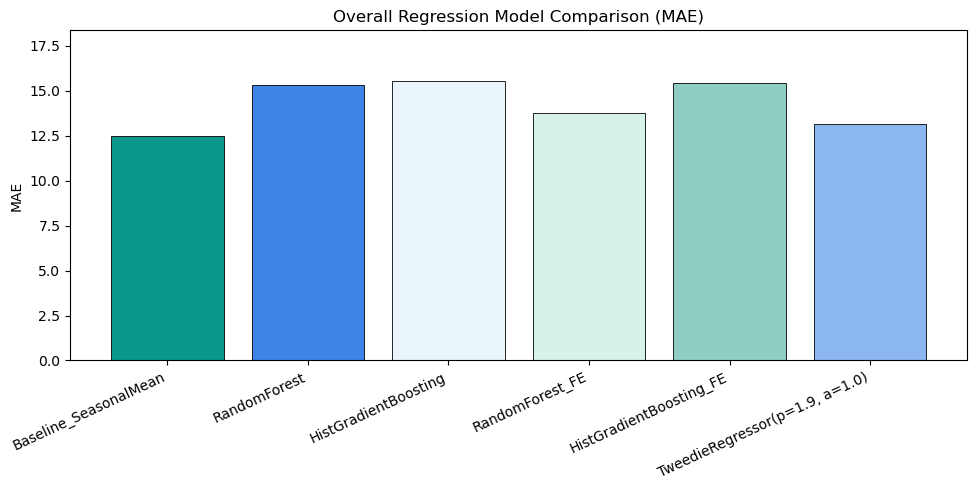

In [29]:
GREEN_LIGHT = "#D7F2E9"
GREEN_DARK  = "#0A968B"
BLUE_LIGHT  = "#EAF4FB"
BLUE_DARK   = "#3D84E6"

tweedie_model_name = tweedie_result_row.iloc[0]["Model"]

overall_reg = pd.concat([
    results_all[results_all["city"] == "overall"][["model", "MAE", "RMSE"]],
    results_fe[results_fe["city"] == "overall"][["model", "MAE", "RMSE"]],
    pd.DataFrame([{
        "model": tweedie_model_name,
        "MAE": tweedie_result_row.iloc[0]["Overall_MAE"],
        "RMSE": tweedie_result_row.iloc[0]["Overall_RMSE"]
    }])
], ignore_index=True)

plot_order = [
    "Baseline_SeasonalMean",
    "RandomForest",
    "HistGradientBoosting",
    "RandomForest_FE",
    "HistGradientBoosting_FE",
    tweedie_model_name
]

overall_reg = (
    overall_reg[overall_reg["model"].isin(plot_order)]
    .drop_duplicates(subset=["model"])
    .copy()
)

overall_reg["model"] = pd.Categorical(
    overall_reg["model"],
    categories=plot_order,
    ordered=True
)
overall_reg = overall_reg.sort_values("model")

bar_colors = [
    GREEN_DARK,
    BLUE_DARK,
    BLUE_LIGHT,
    GREEN_LIGHT,
    "#8FCFC3",
    "#8DB7F0"
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    overall_reg["model"],
    overall_reg["MAE"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Overall Regression Model Comparison (MAE)")
ax.set_ylabel("MAE")
ax.set_xlabel("")
ax.set_ylim(0, overall_reg["MAE"].max() * 1.18)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

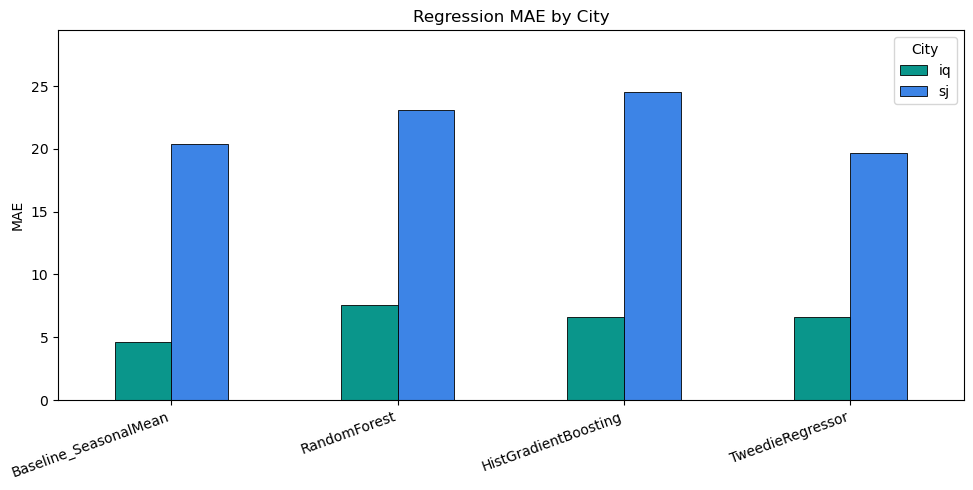

In [30]:
reg_city = pd.concat([
    results_all[results_all["city"].isin(["iq", "sj"])][["model", "city", "MAE"]],
    pd.DataFrame([
        {"model": "TweedieRegressor", "city": "iq", "MAE": tweedie_city.loc[tweedie_city["city"]=="iq", "MAE"].iloc[0]},
        {"model": "TweedieRegressor", "city": "sj", "MAE": tweedie_city.loc[tweedie_city["city"]=="sj", "MAE"].iloc[0]},
    ])
], ignore_index=True)

reg_city = reg_city[reg_city["model"].isin([
    "Baseline_SeasonalMean",
    "RandomForest",
    "HistGradientBoosting",
    "TweedieRegressor"
])].copy()

pivot_reg_city = reg_city.pivot(index="model", columns="city", values="MAE").reindex(
    ["Baseline_SeasonalMean", "RandomForest", "HistGradientBoosting", "TweedieRegressor"]
)

ax = pivot_reg_city.plot(
    kind="bar",
    figsize=(10, 5),
    color=[GREEN_DARK, BLUE_DARK],
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Regression MAE by City")
ax.set_ylabel("MAE")
ax.set_xlabel("")
ax.set_ylim(0, pivot_reg_city.max().max() * 1.20)
plt.xticks(rotation=20, ha="right")
ax.legend(title="City")
plt.tight_layout()
plt.show()

# `4 Classification Extension: Predicting Outbreak Risk`

Classification Step 1:

Define outbreak labels (per city, based on 75th percentile of training set)

In [31]:
cls_train = reg_train.copy()
cls_val   = reg_val.copy()

# 1) Compute per-city outbreak threshold from the training set
outbreak_thresholds = cls_train.groupby('city')['total_cases'].quantile(0.75).to_dict()
print("Outbreak thresholds by city:")
print(outbreak_thresholds)

# 2) Generate binary labels: >= threshold → 1, otherwise → 0
cls_train['outbreak'] = cls_train.apply(
    lambda r: int(r['total_cases'] >= outbreak_thresholds[r['city']]),
    axis=1
)
cls_val['outbreak'] = cls_val.apply(
    lambda r: int(r['total_cases'] >= outbreak_thresholds[r['city']]),
    axis=1
)

# 3) Reuse regression feature columns for the classifier
cls_feature_cols = reg_feature_cols.copy()

# 4) Check class distribution in train and validation sets
print("\nTrain class balance by city:")
display(
    cls_train.groupby('city')['outbreak']
    .value_counts(normalize=True)
    .rename('ratio')
    .reset_index()
)

print("\nValidation class balance by city:")
display(
    cls_val.groupby('city')['outbreak']
    .value_counts(normalize=True)
    .rename('ratio')
    .reset_index()
)

print("\nTrain outbreak counts by city:")
display(
    cls_train.groupby('city')['outbreak']
    .value_counts()
    .rename('count')
    .reset_index()
)

print("\nValidation outbreak counts by city:")
display(
    cls_val.groupby('city')['outbreak']
    .value_counts()
    .rename('count')
    .reset_index()
)

Outbreak thresholds by city:
{'iq': 9.0, 'sj': 37.0}

Train class balance by city:


,city,outbreak,ratio
0,iq,0,0.724359
1,iq,1,0.275641
2,sj,0,0.745475
3,sj,1,0.254525



Validation class balance by city:


,city,outbreak,ratio
0,iq,0,0.730769
1,iq,1,0.269231
2,sj,0,0.692308
3,sj,1,0.307692



Train outbreak counts by city:


,city,outbreak,count
0,iq,0,339
1,iq,1,129
2,sj,0,659
3,sj,1,225



Validation outbreak counts by city:


,city,outbreak,count
0,iq,0,38
1,iq,1,14
2,sj,0,36
3,sj,1,16


### Classification Step 2: Unified classification evaluation function + Logistic Regression

In [32]:

def evaluate_citywise_classifier(train_df, val_df, model_factory, feature_cols, threshold=0.5):
    city_rows  = []
    pred_parts = []

    for city in sorted(train_df['city'].unique()):
        tr = train_df[train_df['city'] == city].copy()
        va = val_df[val_df['city'] == city].copy()

        X_tr = tr[feature_cols]
        y_tr = tr['outbreak'].values
        X_va = va[feature_cols]
        y_va = va['outbreak'].values

        model = model_factory()
        model.fit(X_tr, y_tr)

        # Probability output
        y_prob = model.predict_proba(X_va)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        row = {
            'city':      city,
            'Precision': precision_score(y_va, y_pred, zero_division=0),
            'Recall':    recall_score(y_va, y_pred, zero_division=0),
            'F1':        f1_score(y_va, y_pred, zero_division=0),
            'ROC_AUC':   roc_auc_score(y_va, y_prob) if len(np.unique(y_va)) > 1 else np.nan
        }
        city_rows.append(row)

        tmp = va[['city']].copy()
        tmp['y_true'] = y_va
        tmp['y_prob'] = y_prob
        tmp['y_pred'] = y_pred
        pred_parts.append(tmp)

    pred_df = pd.concat(pred_parts, ignore_index=True)
    overall = {
        'Overall_Precision': precision_score(pred_df['y_true'], pred_df['y_pred'], zero_division=0),
        'Overall_Recall':    recall_score(pred_df['y_true'], pred_df['y_pred'], zero_division=0),
        'Overall_F1':        f1_score(pred_df['y_true'], pred_df['y_pred'], zero_division=0),
        'Overall_ROC_AUC':   roc_auc_score(pred_df['y_true'], pred_df['y_prob'])
                             if len(np.unique(pred_df['y_true'])) > 1 else np.nan
    }
    city_df = pd.DataFrame(city_rows)
    return overall, city_df, pred_df


def logit_factory():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=42
        ))
    ])


logit_overall, logit_city, logit_pred = evaluate_citywise_classifier(
    cls_train, cls_val, logit_factory, cls_feature_cols, threshold=0.5
)

print("Logistic Regression - Overall:")
print(logit_overall)
print("\nLogistic Regression - Per City:")
display(logit_city)
print("\nPrediction sample:")
display(logit_pred.head())

Logistic Regression - Overall:
{'Overall_Precision': 0.45714285714285713, 'Overall_Recall': 0.5333333333333333, 'Overall_F1': 0.49230769230769234, 'Overall_ROC_AUC': np.float64(0.7423423423423423)}

Logistic Regression - Per City:


,city,Precision,Recall,F1,ROC_AUC
0,iq,0.4,0.857143,0.545455,0.804511
1,sj,0.8,0.250000,0.380952,0.925347



Prediction sample:


,city,y_true,y_prob,y_pred
0,iq,0,0.360604,0
1,iq,0,0.696569,1
2,iq,0,0.917275,1
3,iq,0,0.738054,1
4,iq,0,0.858947,1


### Classification Step 3: Random Forest Classifier

In [33]:
from sklearn.ensemble import RandomForestClassifier


def rf_clf_factory():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            random_state=42,
            class_weight='balanced_subsample',
            n_jobs=-1
        ))
    ])

rfc_overall, rfc_city, rfc_pred = evaluate_citywise_classifier(
    cls_train,
    cls_val,
    rf_clf_factory,
    cls_feature_cols,
    threshold=0.5
)

print("Random Forest Classifier - Overall:")
print(rfc_overall)

print("\nRandom Forest Classifier - Per City:")
display(rfc_city)

print("\nPrediction sample:")
display(rfc_pred.head())

Random Forest Classifier - Overall:
{'Overall_Precision': 0.3333333333333333, 'Overall_Recall': 0.06666666666666667, 'Overall_F1': 0.1111111111111111, 'Overall_ROC_AUC': np.float64(0.7963963963963964)}

Random Forest Classifier - Per City:


,city,Precision,Recall,F1,ROC_AUC
0,iq,0.333333,0.142857,0.2,0.783835
1,sj,0.000000,0.000000,0.0,0.991319



Prediction sample:


,city,y_true,y_prob,y_pred
0,iq,0,0.095673,0
1,iq,0,0.074595,0
2,iq,0,0.111796,0
3,iq,0,0.077712,0
4,iq,0,0.066371,0


In [34]:
classification_results = pd.DataFrame([
    {'Model': 'LogisticRegression', **logit_overall},
    {'Model': 'RandomForestClassifier', **rfc_overall}
])

classification_results = classification_results.sort_values(
    by=['Overall_F1', 'Overall_ROC_AUC'],
    ascending=[False, False]
).reset_index(drop=True)

display(classification_results)

,Model,Overall_Precision,Overall_Recall,Overall_F1,Overall_ROC_AUC
0,LogisticRegression,0.457143,0.533333,0.492308,0.742342
1,RandomForestClassifier,0.333333,0.066667,0.111111,0.796396


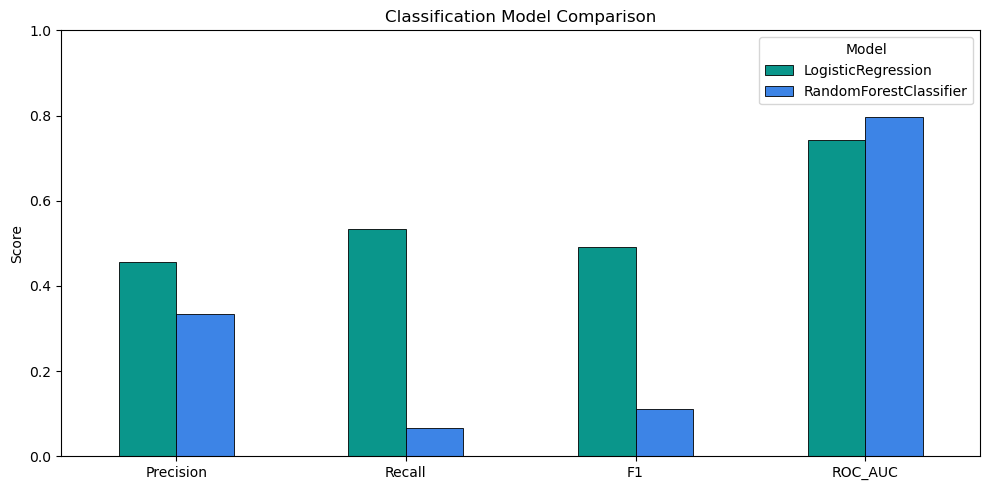

In [35]:
clf_plot = classification_results.copy()
clf_plot = clf_plot.rename(columns={
    "Overall_Precision": "Precision",
    "Overall_Recall": "Recall",
    "Overall_F1": "F1",
    "Overall_ROC_AUC": "ROC_AUC"
})

clf_long = clf_plot.melt(
    id_vars="Model",
    value_vars=["Precision", "Recall", "F1", "ROC_AUC"],
    var_name="Metric",
    value_name="Score"
)

pivot_clf = clf_long.pivot(index="Metric", columns="Model", values="Score").loc[
    ["Precision", "Recall", "F1", "ROC_AUC"]
]

ax = pivot_clf.plot(
    kind="bar",
    figsize=(10, 5),
    color=[GREEN_DARK, BLUE_DARK],
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Classification Model Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, max(1.0, pivot_clf.max().max() * 1.18))
plt.xticks(rotation=0)
ax.legend(title="Model")
plt.tight_layout()
plt.show()

# `5 Clustering`

In addition to supervised learning, this project includes an unsupervised learning extension using clustering. The purpose of clustering is to identify hidden environmental patterns in the dengue dataset without using the target label during training. This helps reveal whether certain combinations of climate and vegetation conditions are associated with different dengue risk levels.


In [36]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [37]:
# --------------------------------------------------
# Clustering Step 1:
# Prepare unsupervised clustering using the original training data
# --------------------------------------------------

# 1) Use the original training set (not reg_train / train_fe)
#    Raw climate variables are more interpretable for clustering
cluster_df = train_df.copy()

# 2) Select raw environmental/climate features for clustering
cluster_feature_cols = [
    c for c in cluster_df.columns
    if c not in ['city', 'year', 'weekofyear', 'week_start_date', 'total_cases']
    and pd.api.types.is_numeric_dtype(cluster_df[c])
]
print("Cluster feature count:", len(cluster_feature_cols))
print("Cluster features:", cluster_feature_cols)

# 3) Impute missing values and standardize
cluster_imputer = SimpleImputer(strategy='median')
cluster_scaler  = StandardScaler()

X_cluster_raw    = cluster_df[cluster_feature_cols]
X_cluster_imp    = cluster_imputer.fit_transform(X_cluster_raw)
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster_imp)
print("Clustering matrix shape:", X_cluster_scaled.shape)

# 4) Silhouette scores across different values of K
sil_rows = []
for k in [2, 3, 4, 5, 6]:
    km     = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_cluster_scaled)
    sil    = silhouette_score(X_cluster_scaled, labels)
    sil_rows.append({'k': k, 'silhouette_score': sil})

silhouette_results = pd.DataFrame(sil_rows).sort_values(
    'silhouette_score', ascending=False
).reset_index(drop=True)
display(silhouette_results)

Cluster feature count: 20
Cluster features: ['ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k', 'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2', 'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm', 'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k', 'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c', 'station_min_temp_c', 'station_precip_mm']
Clustering matrix shape: (1352, 20)


C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

,k,silhouette_score
0,2,0.323827
1,3,0.301422
2,4,0.296498
3,5,0.273322
4,6,0.265976


### Clustering Step 2: Run final clustering with the best K and summarize results

In [38]:

best_k = int(silhouette_results.iloc[0]['k'])
print("Best k selected from silhouette:", best_k)

# 1) Final KMeans
final_kmeans  = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = final_kmeans.fit_predict(X_cluster_scaled)

# 2) Append cluster labels back to the original training data
cluster_results_df = cluster_df.copy()
cluster_results_df['cluster'] = cluster_labels
print("\nCluster counts:")
display(
    cluster_results_df['cluster']
    .value_counts()
    .sort_index()
    .rename('count')
    .reset_index()
    .rename(columns={'index': 'cluster'})
)

# 3) Case count statistics per cluster
cluster_case_summary = cluster_results_df.groupby('cluster')['total_cases'].agg(
    count='size',
    mean_cases='mean',
    median_cases='median',
    std_cases='std',
    max_cases='max'
).reset_index().sort_values('mean_cases', ascending=False)
print("\nCluster vs dengue case summary:")
display(cluster_case_summary)

# 4) City composition per cluster
cluster_city_summary = pd.crosstab(
    cluster_results_df['cluster'],
    cluster_results_df['city'],
    normalize='index'
).round(3)
print("\nCluster city composition (row %):")
display(cluster_city_summary)

# 5) Climate/environmental profile per cluster (raw-scale means)
cluster_feature_profile = cluster_results_df.groupby('cluster')[cluster_feature_cols].mean()
print("\nCluster feature profile (raw-scale means):")
display(cluster_feature_profile)

# 6) Z-score profile relative to the overall mean — easier to interpret
cluster_feature_profile_z = (
    cluster_results_df.groupby('cluster')[cluster_feature_cols].mean()
    - cluster_results_df[cluster_feature_cols].mean()
) / cluster_results_df[cluster_feature_cols].std()
print("\nCluster feature profile (relative to overall mean, approx z-score):")
display(cluster_feature_profile_z.round(2))

Best k selected from silhouette: 2

Cluster counts:


C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


,cluster,count
0,0,885
1,1,467



Cluster vs dengue case summary:


,cluster,count,mean_cases,median_cases,std_cases,max_cases
0,0,885,33.933333,19.0,52.004406,461
1,1,467,7.970021,5.0,11.624635,116


...

city,iq,sj
cluster,,
0,0.003,0.997
1,0.996,0.004



Cluster feature profile (raw-scale means):


,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
cluster,,,,,,,,,,,,,,,,,,,,
0,0.061826,0.072254,0.177777,0.166297,35.094788,299.138712,299.252169,295.116402,301.375457,297.288813,30.479920,78.717353,35.094788,16.55922,2.503979,27.010160,6.786089,31.628767,22.584018,26.554909
1,0.264283,0.236442,0.249340,0.265589,65.715225,297.815831,299.068951,295.406390,306.983512,292.795503,56.039229,88.464215,65.715225,17.00290,9.201407,27.484181,10.487326,33.919256,21.177106,66.062009



Cluster feature profile (relative to overall mean, approx z-score):


,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
cluster,,,,,,,,,,,,,,,,,,,,
0,-0.58,-0.5,-0.34,-0.42,-0.24,0.34,0.05,-0.07,-0.61,0.61,-0.21,-0.48,-0.24,-0.10,-0.66,-0.12,-0.59,-0.41,0.31,-0.28
1,0.88,0.9,0.64,0.78,0.45,-0.64,-0.10,0.12,1.15,-1.14,0.39,0.90,0.45,0.19,1.23,0.25,1.19,0.79,-0.58,0.54


### 5.2 City-specific Clustering

Why City-Specific Clustering Is Also Needed: A single clustering model on the full training set may capture broad differences between cities rather than the more subtle environmental regimes within each city. Because San Juan and Iquitos have different climate patterns and dengue dynamics, clustering the pooled data may hide local structure.

To address this issue, the analysis also performs city-specific clustering. For each city, the same preprocessing workflow is repeated: numeric environmental variables are selected, missing values are imputed, features are standardized, and multiple values of \(K\) are evaluated using silhouette score. This produces a more localized and interpretable view of environmental patterns within each city.

In [39]:
# --------------------------------------------------
# City-specific Clustering Step 1:
# Search for the optimal K per city
# --------------------------------------------------

# Rebuild cluster_feature_cols if not already in memory
if 'cluster_feature_cols' not in globals():
    cluster_feature_cols = [
        c for c in train_df.columns
        if c not in ['city', 'year', 'weekofyear', 'week_start_date', 'total_cases']
        and pd.api.types.is_numeric_dtype(train_df[c])
    ]

city_silhouette_tables = []
city_best_k = {}

for city in sorted(train_df['city'].unique()):
    city_df = train_df[train_df['city'] == city].copy()

    X_city_raw = city_df[cluster_feature_cols]
    imputer = SimpleImputer(strategy='median')
    scaler  = StandardScaler()
    X_city_imp    = imputer.fit_transform(X_city_raw)
    X_city_scaled = scaler.fit_transform(X_city_imp)

    rows = []
    for k in [2, 3, 4, 5, 6]:
        km     = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = km.fit_predict(X_city_scaled)
        sil    = silhouette_score(X_city_scaled, labels)
        rows.append({'city': city, 'k': k, 'silhouette_score': sil})

    city_k_df = pd.DataFrame(rows).sort_values(
        'silhouette_score', ascending=False
    ).reset_index(drop=True)

    city_best_k[city] = int(city_k_df.iloc[0]['k'])
    city_silhouette_tables.append(city_k_df)

city_silhouette_results = pd.concat(city_silhouette_tables, ignore_index=True)
print("Best K by city:")
print(city_best_k)
print("\nCity-specific silhouette results:")
display(city_silhouette_results)

C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

Best K by city:
{'iq': 2, 'sj': 2}

City-specific silhouette results:


C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,city,k,silhouette_score
0,iq,2,0.217978
1,iq,3,0.196910
2,iq,4,0.149831
3,iq,5,0.138725
4,iq,6,0.135621
5,sj,2,0.296903
6,sj,3,0.267966
7,sj,4,0.192789
8,sj,5,0.123830
9,sj,6,0.120101


In [40]:
# --------------------------------------------------
# City-specific Clustering Step 2:
# Run final clustering per city using the best K, and output summaries
# --------------------------------------------------
city_cluster_case_tables    = []
city_cluster_profile_tables = []
city_cluster_count_tables   = []
city_clustered_data         = {}

for city in sorted(train_df['city'].unique()):
    city_df = train_df[train_df['city'] == city].copy()

    X_city_raw    = city_df[cluster_feature_cols]
    imputer       = SimpleImputer(strategy='median')
    scaler        = StandardScaler()
    X_city_imp    = imputer.fit_transform(X_city_raw)
    X_city_scaled = scaler.fit_transform(X_city_imp)

    best_k           = city_best_k[city]
    km               = KMeans(n_clusters=best_k, random_state=42, n_init=20)
    city_df['cluster'] = km.fit_predict(X_city_scaled)

    # Save original data with cluster labels attached
    city_clustered_data[city] = city_df.copy()

    # 1) Sample count per cluster
    count_df = (
        city_df['cluster']
        .value_counts()
        .sort_index()
        .rename('count')
        .reset_index()
        .rename(columns={'index': 'cluster'})
    )
    count_df['city'] = city
    city_cluster_count_tables.append(count_df)

    # 2) Case count statistics per cluster
    case_df = city_df.groupby('cluster')['total_cases'].agg(
        count='size',
        mean_cases='mean',
        median_cases='median',
        std_cases='std',
        max_cases='max'
    ).reset_index()
    case_df['city'] = city
    city_cluster_case_tables.append(case_df)

    # 3) Climate profile per cluster (z-score relative to that city's overall mean)
    profile_z = (
        city_df.groupby('cluster')[cluster_feature_cols].mean()
        - city_df[cluster_feature_cols].mean()
    ) / city_df[cluster_feature_cols].std()
    profile_z          = profile_z.round(2).reset_index()
    profile_z['city']  = city
    city_cluster_profile_tables.append(profile_z)

city_cluster_counts       = pd.concat(city_cluster_count_tables,   ignore_index=True)
city_cluster_case_summary = pd.concat(city_cluster_case_tables,    ignore_index=True)
city_cluster_profile_z    = pd.concat(city_cluster_profile_tables, ignore_index=True)

print("Cluster counts within each city:")
display(city_cluster_counts.sort_values(['city', 'cluster']).reset_index(drop=True))

print("\nCluster vs dengue cases within each city:")
display(city_cluster_case_summary.sort_values(['city', 'cluster']).reset_index(drop=True))

print("\nCluster climate profile within each city (z-score relative to that city's overall mean):")
display(city_cluster_profile_z.sort_values(['city', 'cluster']).reset_index(drop=True))

C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\vincent\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Cluster counts within each city:


,cluster,count,city
0,0,181,iq
1,1,287,iq
2,0,523,sj
3,1,361,sj



Cluster vs dengue cases within each city:


,cluster,count,mean_cases,median_cases,std_cases,max_cases,city
0,0,181,6.044199,3.0,9.198927,63,iq
1,1,287,8.864111,5.0,12.200209,116,iq
2,0,523,41.030593,22.0,62.324904,461,sj
3,1,361,23.977839,17.0,28.857111,288,sj



Cluster climate profile within each city (z-score relative to that city's overall mean):


,cluster,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,city
0,0,0.41,0.38,0.40,0.42,-0.54,0.56,0.58,-0.75,0.84,...,-1.00,-0.54,-0.74,0.97,0.15,0.69,0.47,-0.48,-0.30,iq
1,1,-0.26,-0.24,-0.26,-0.26,0.35,-0.36,-0.37,0.48,-0.54,...,0.64,0.35,0.47,-0.62,-0.09,-0.43,-0.30,0.31,0.19,iq
2,0,-0.00,0.02,-0.02,-0.02,0.32,0.68,0.67,0.71,0.65,...,0.44,0.32,0.72,-0.02,0.68,-0.04,0.54,0.66,0.22,sj
3,1,0.00,-0.03,0.03,0.02,-0.47,-0.97,-0.96,-1.02,-0.93,...,-0.63,-0.47,-1.03,0.02,-0.98,0.06,-0.77,-0.94,-0.31,sj


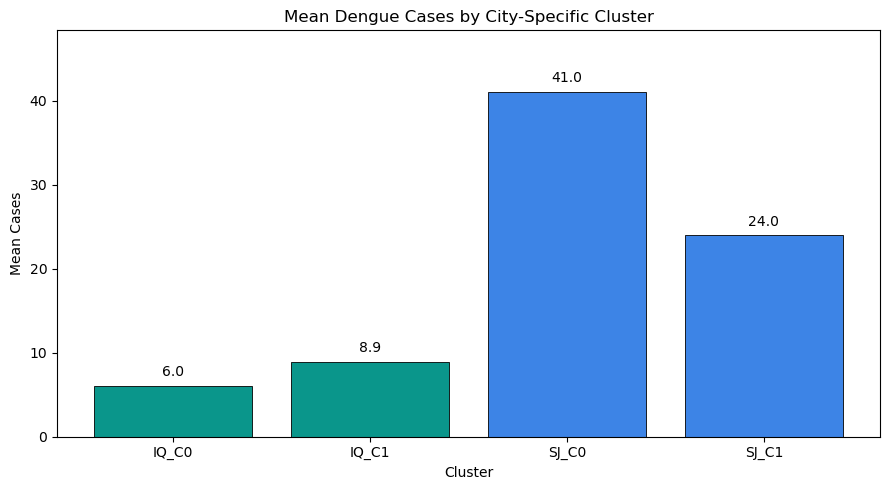

In [41]:
cluster_plot = city_cluster_case_summary.copy()
cluster_plot["cluster_label"] = cluster_plot["city"].str.upper() + "_C" + cluster_plot["cluster"].astype(str)

bar_colors = [GREEN_DARK if c.lower() == "iq" else BLUE_DARK for c in cluster_plot["city"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    cluster_plot["cluster_label"],
    cluster_plot["mean_cases"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Mean Dengue Cases by City-Specific Cluster")
ax.set_ylabel("Mean Cases")
ax.set_xlabel("Cluster")
ax.set_ylim(0, cluster_plot["mean_cases"].max() * 1.18)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + cluster_plot["mean_cases"].max() * 0.02,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

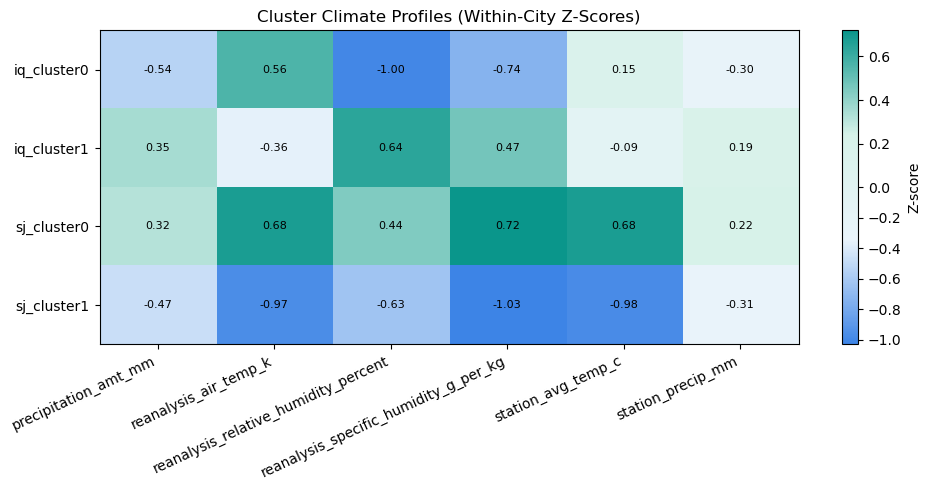

In [42]:
import matplotlib.colors as mcolors

heatmap_df = city_cluster_profile_z.copy()
heatmap_df["label"] = heatmap_df["city"] + "_cluster" + heatmap_df["cluster"].astype(str)

selected_features = [
    "precipitation_amt_mm",
    "reanalysis_air_temp_k",
    "reanalysis_relative_humidity_percent",
    "reanalysis_specific_humidity_g_per_kg",
    "station_avg_temp_c",
    "station_precip_mm"
]

mat = heatmap_df[selected_features].to_numpy()

cmap = mcolors.LinearSegmentedColormap.from_list(
    "ppt_diverging",
    [BLUE_DARK, BLUE_LIGHT, GREEN_LIGHT, GREEN_DARK]
)

norm = mcolors.TwoSlopeNorm(vmin=mat.min(), vcenter=0, vmax=mat.max())

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(mat, aspect="auto", cmap=cmap, norm=norm)

cbar = plt.colorbar(im)
cbar.set_label("Z-score")

ax.set_yticks(range(len(heatmap_df["label"])))
ax.set_yticklabels(heatmap_df["label"])
ax.set_xticks(range(len(selected_features)))
ax.set_xticklabels(selected_features, rotation=25, ha="right")
ax.set_title("Cluster Climate Profiles (Within-City Z-Scores)")

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat[i, j]
        ax.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            fontsize=8,
            color="black"
        )

plt.tight_layout()
plt.show()

# 6. Model Performance Optimization

In [45]:
from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import RandomForestRegressor

rf_search_rows = []

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 2, 4]
}

for params in ParameterGrid(param_grid):
    overall, city_df, pred_df = evaluate_citywise_regressor(
        reg_train,
        reg_val,
        model_factory=lambda params=params: RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1
        ),
        feature_cols=reg_feature_cols
    )

    rf_search_rows.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "Overall_MAE": overall["Overall_MAE"],
        "Overall_RMSE": overall["Overall_RMSE"]
    })

rf_search = pd.DataFrame(rf_search_rows).sort_values(
    ["Overall_MAE", "Overall_RMSE"]
).reset_index(drop=True)

display(rf_search.head(10))

,n_estimators,max_depth,min_samples_leaf,Overall_MAE,Overall_RMSE
0,200,5.0,1,10.586538,20.867946
1,200,5.0,2,10.750000,21.516541
2,200,10.0,1,10.846154,21.156014
3,500,5.0,1,11.067308,21.714272
4,500,5.0,2,11.125000,21.939383
5,200,10.0,2,11.134615,21.511625
6,200,NaN,1,11.230769,21.680370
7,200,NaN,2,11.240385,21.893756
8,500,10.0,1,11.365385,22.122039
9,200,5.0,4,11.423077,22.676233


In [47]:
best_n_estimators = int(rf_search.iloc[0]["n_estimators"])

best_max_depth_raw = rf_search.iloc[0]["max_depth"]
best_max_depth = None if pd.isna(best_max_depth_raw) else int(best_max_depth_raw)

best_min_samples_leaf = int(rf_search.iloc[0]["min_samples_leaf"])

print("Best Random Forest parameters:")
print("n_estimators =", best_n_estimators)
print("max_depth =", best_max_depth)
print("min_samples_leaf =", best_min_samples_leaf)

Best Random Forest parameters:
n_estimators = 200
max_depth = 5
min_samples_leaf = 1


In [48]:
def best_rf_factory():
    return RandomForestRegressor(
        n_estimators=best_n_estimators,
        max_depth=best_max_depth,
        min_samples_leaf=best_min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

rf_opt_overall, rf_opt_city, rf_opt_pred = evaluate_citywise_regressor(
    reg_train,
    reg_val,
    best_rf_factory,
    reg_feature_cols
)

print("Optimized Random Forest overall performance:")
print(rf_opt_overall)

print("\nOptimized Random Forest per-city performance:")
display(rf_opt_city)

print("\nPrediction sample:")
display(rf_opt_pred.head())

Optimized Random Forest overall performance:
{'Overall_MAE': 10.586538461538462, 'Overall_RMSE': np.float64(20.86794560674706)}

Optimized Random Forest per-city performance:


,city,MAE,RMSE
0,iq,6.480769,8.878453
1,sj,14.692308,28.144544



Prediction sample:


,city,total_cases,pred
0,iq,1,4.0
1,iq,2,4.0
2,iq,0,4.0
3,iq,0,4.0
4,iq,3,4.0
